# Feature Engineering & Customer Segmentation

## Objectives

- Load cleaned dataset
- Create new business features
- Perform customer segmentation using K-Means
- Identify the optimal number of clusters
- Add cluster labels as a new feature
- Build preprocessing pipeline
- Split the dataset

Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

Load Clean Dataset

In [2]:
df = pd.read_csv("../data/processed/df_clean.csv")

print(df.shape)

df.head()

(41188, 20)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Dataset Copy

In [3]:
df_fe = df.copy()

Previous Contact Flag

In [4]:
df_fe["previous_contact"] = np.where(df_fe["previous"] > 0, 1, 0)

df_fe["previous_contact"].value_counts()

previous_contact
0    35563
1     5625
Name: count, dtype: int64

Multiple Contacts Flag

In [5]:
df_fe["multiple_contacts"] = np.where(df_fe["campaign"] > 1, 1, 0)

df_fe["multiple_contacts"].value_counts()

multiple_contacts
1    23546
0    17642
Name: count, dtype: int64

Senior Citizen Flag

In [6]:
df_fe["is_senior"] = np.where(df_fe["age"] >= 60, 1, 0)

df_fe["is_senior"].value_counts()

is_senior
0    39995
1     1193
Name: count, dtype: int64

Long Employment Indicator

In [7]:
stable_jobs = [
    "admin.",
    "technician",
    "management",
    "retired"
]

df_fe["stable_job"] = np.where(
    df_fe["job"].isin(stable_jobs),
    1,
    0
)

df_fe["stable_job"].value_counts()

stable_job
1    21809
0    19379
Name: count, dtype: int64

Contact Season

In [8]:
summer = ["may", "jun", "jul", "aug"]

df_fe["summer_contact"] = np.where(
    df_fe["month"].isin(summer),
    1,
    0
)

df_fe["summer_contact"].value_counts()

summer_contact
1    32439
0     8749
Name: count, dtype: int64

View Dataset

In [9]:
df_fe.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,previous_contact,multiple_contacts,is_senior,stable_job,summer_contact
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,0,0,0,0,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,0,0,0,0,1
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,0,0,0,0,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,0,0,0,1,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,no,0,0,0,0,1


Feature Summary

In [10]:
new_features = [
    "previous_contact",
    "multiple_contacts",
    "is_senior",
    "stable_job",
    "summer_contact"
]

df_fe[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
previous_contact,41188.0,0.136569,0.343396,0.0,0.0,0.0,0.0,1.0
multiple_contacts,41188.0,0.571671,0.494843,0.0,0.0,1.0,1.0,1.0
is_senior,41188.0,0.028965,0.167709,0.0,0.0,0.0,0.0,1.0
stable_job,41188.0,0.529499,0.499135,0.0,0.0,1.0,1.0,1.0
summer_contact,41188.0,0.787584,0.409023,0.0,1.0,1.0,1.0,1.0


Save Intermediate Dataset

In [11]:
df_fe.to_csv(
    "../data/processed/feature_engineered.csv",
    index=False
)

print("Feature engineered dataset saved.")

Feature engineered dataset saved.


Select Features for Clustering

In [12]:
cluster_features = [
    "age",
    "campaign",
    "pdays",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

X_cluster = df_fe[cluster_features]

Feature Scaling

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

Elbow Method

In [14]:
inertia = []

for k in range(3, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

Plot Elbow Curve

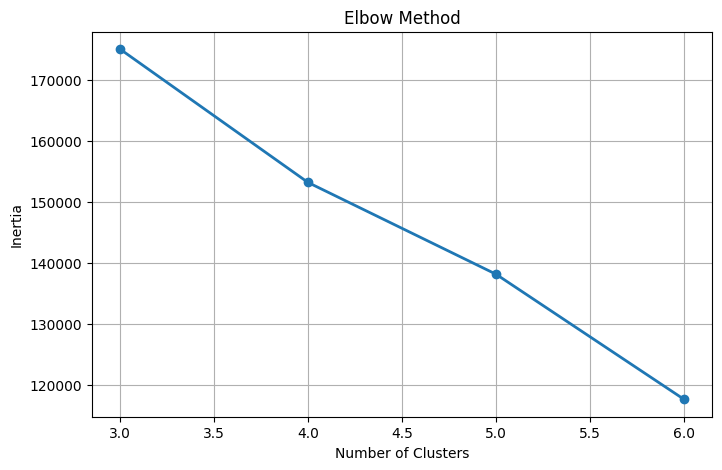

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    range(3,7),
    inertia,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

Silhouette Score

In [16]:
scores = []

for k in range(3,7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

    print(f"k = {k}  |  Silhouette Score = {score:.4f}")

k = 3  |  Silhouette Score = 0.4841
k = 4  |  Silhouette Score = 0.4635
k = 5  |  Silhouette Score = 0.2943
k = 6  |  Silhouette Score = 0.3056


Plot Silhouette Scores

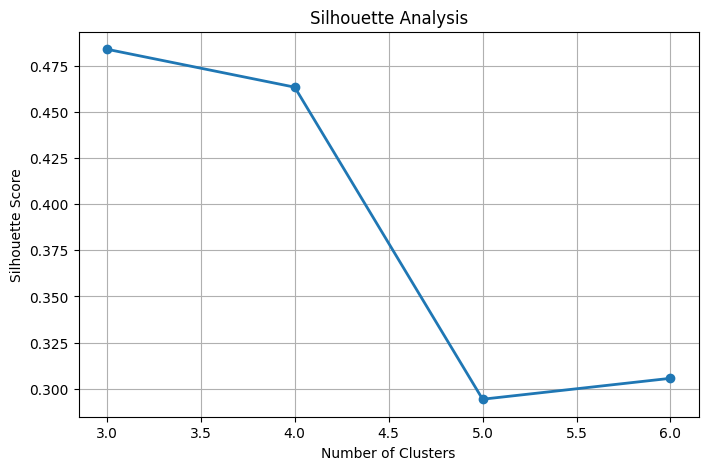

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    range(3,7),
    scores,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

best k = 3

cluster

In [18]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df_fe["cluster"] = kmeans.fit_predict(X_scaled)

df_fe["cluster"].value_counts()

cluster
1    27645
0    12003
2     1540
Name: count, dtype: int64

Cluster Profile

In [19]:
cluster_profile = (
    df_fe
    .groupby("cluster")[cluster_features]
    .mean()
    .round(2)
)

cluster_profile

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
cluster,,,,,,,,,
0,39.39,2.13,999.00,0.32,-2.03,92.99,-43.19,1.20,5077.97
1,40.19,2.80,999.00,0.03,1.12,93.84,-39.46,4.82,5213.42
2,41.92,1.83,22.13,1.69,-2.09,93.35,-38.32,0.98,5028.58


Cluster Size

In [20]:
cluster_size = (
    df_fe["cluster"]
    .value_counts()
    .sort_index()
)

cluster_size

cluster
0    12003
1    27645
2     1540
Name: count, dtype: int64

Customer Cluster Distribution

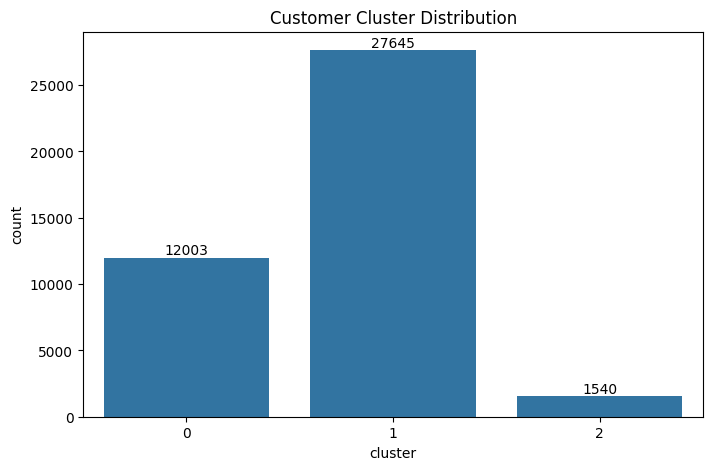

In [21]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_fe,
    x="cluster"
)

plt.title("Customer Cluster Distribution")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Save Clustered dataset 

In [22]:
df_fe.to_csv(
    "../data/processed/clustered_data.csv",
    index=False
)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


CLUSTER SUMMARY

In [23]:
print("CLUSTER SUMMARY")

print(cluster_profile)

CLUSTER SUMMARY
           age  campaign   pdays  previous  emp.var.rate  cons.price.idx  \
cluster                                                                    
0        39.39      2.13  999.00      0.32         -2.03           92.99   
1        40.19      2.80  999.00      0.03          1.12           93.84   
2        41.92      1.83   22.13      1.69         -2.09           93.35   

         cons.conf.idx  euribor3m  nr.employed  
cluster                                         
0               -43.19       1.20      5077.97  
1               -39.46       4.82      5213.42  
2               -38.32       0.98      5028.58  


# Cluster Interpretation

## Cluster 0 - Moderate Engagement Customers

- Moderate campaign activity
- Some previous interactions
- Lower interest rate environment
- Medium marketing potential

## Cluster 1 - Low Engagement Customers

- Very few previous contacts
- Higher economic indicators
- Highest Euribor rate
- Lower response potential
- May require more personalized campaigns

## Cluster 2 - High Potential Customers

- Recently contacted customers
- Highest number of previous contacts
- Lower Euribor rate
- Strong candidates for future marketing campaigns

Cluster vs Target Analysis

In [24]:
cluster_target = (
    pd.crosstab(
        df_fe["cluster"],
        df_fe["y"],
        normalize="index"
    ) * 100
).round(2)

cluster_target

y,no,yes
cluster,,
0,80.55,19.45
1,95.17,4.83
2,36.95,63.05


Heatmap

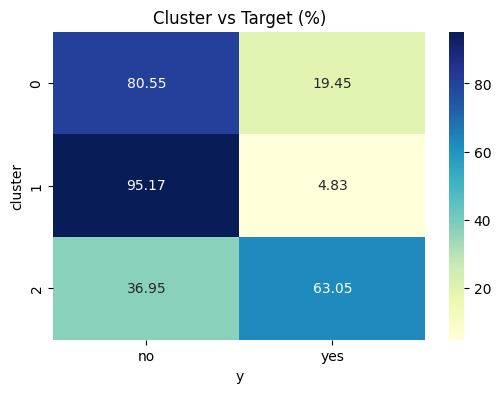

In [25]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cluster_target,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Cluster vs Target (%)")

plt.show()

Save Results

In [26]:
cluster_profile.to_csv(
    "../reports/cluster_profile.csv"
)

cluster_target.to_csv(
    "../reports/cluster_target_analysis.csv"
)

print("Cluster reports saved successfully.")

Cluster reports saved successfully.


# Business Insight

Cluster analysis shows that different customer groups have different subscription rates.

This confirms that customer segmentation provides valuable information that can improve marketing campaign targeting.

The cluster label will therefore be used as an additional feature during predictive modeling.